In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath("C://Users//pc//Desktop//Week 3//insurance-risk-analytics//src//"))

In [46]:
from src.data_loader import load_data
from src.modeling import *

print('Functions imported successfully!')
print()

Functions imported successfully!



In [4]:
# Load the insurance data
df = load_data('C:/Users/pc/Desktop/Week 3/insurance-risk-analytics/data/insurance_data.csv')
df.head()

,customerid,age,gender,province,vehicletype,annualincome,riskscore,annualpremium,deductible,ncd,...,claimed,claimamount,totalpremium,totalclaims,covertype,automake,vehiclemodel,customvalueestimate,zipcode,transactiondate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [5]:
df = remove_high_missing_columns(df, threshold=0.5)

In [6]:
df = feature_engineering(df)


In [7]:
df.columns

Index(['customerid', 'age', 'gender', 'province', 'vehicletype',
       'annualincome', 'riskscore', 'annualpremium', 'deductible', 'ncd',
       'pastclaims', 'claimed', 'claimamount', 'totalpremium', 'totalclaims',
       'covertype', 'automake', 'vehiclemodel', 'customvalueestimate',
       'zipcode', 'transactiondate'],
      dtype='str')

In [8]:
severity_df = df[df["totalclaims"] > 0].copy()

In [9]:
target_column = "totalclaims"

X = severity_df.drop(columns=[target_column])

y = severity_df[target_column]

In [10]:
numerical_cols, categorical_cols = separate_features(
    X,
    target_column=None
)


In [11]:
preprocessor = create_preprocessor(
    numerical_cols,
    categorical_cols
)


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1228, 20)
Testing Shape: (307, 20)


In [18]:

linear_model = train_linear_regression(
    preprocessor,
    X_train,
    y_train
)

In [20]:
rf_model = train_random_forest(
    preprocessor,
    X_train,
    y_train
)


Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Random Forest Parameters:
{'model__max_depth': 20, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [23]:
xgb_model = train_xgboost(
    preprocessor,
    X_train,
    y_train
)

Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best XGBoost Parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}


In [24]:
linear_results = evaluate_model(
    linear_model,
    X_test,
    y_test,
    "Linear Regression"
)

rf_results = evaluate_model(
    rf_model,
    X_test,
    y_test,
    "Random Forest"
)

xgb_results = evaluate_model(
    xgb_model,
    X_test,
    y_test,
    "XGBoost"
)


Linear Regression Performance
RMSE: 0.0045
R² Score: 1.0000

Random Forest Performance
RMSE: 103.4659
R² Score: 0.9997

XGBoost Performance
RMSE: 313.9449
R² Score: 0.9972


In [25]:
results = [
    linear_results,
    rf_results,
    xgb_results
]

print("\nFinal Model Comparison")
print("=" * 50)

for result in results:
    print(result)


Final Model Comparison
{'Model': 'Linear Regression', 'RMSE': np.float64(0.004466263612704691), 'R2': 0.999999999999436}
{'Model': 'Random Forest', 'RMSE': np.float64(103.4659166835531), 'R2': 0.9996973292874939}
{'Model': 'XGBoost', 'RMSE': np.float64(313.9448790221086), 'R2': 0.9972133489676688}


In [27]:
best_model = rf_model

In [28]:
X_test_processed = preprocessor.transform(X_test)

In [29]:
feature_names = get_feature_names(
    preprocessor,
    numerical_cols,
    categorical_cols
)


In [ ]:
shap_values, shap_df = compute_shap_values(
    best_model, 
    X_test,            
    feature_names
)

c:\Users\pc\Desktop\Week 3\insurance-risk-analytics\src\modeling.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  from sklearn.compose import ColumnTransformer


SHAP summary plot saved to outputs/shap_summary.png


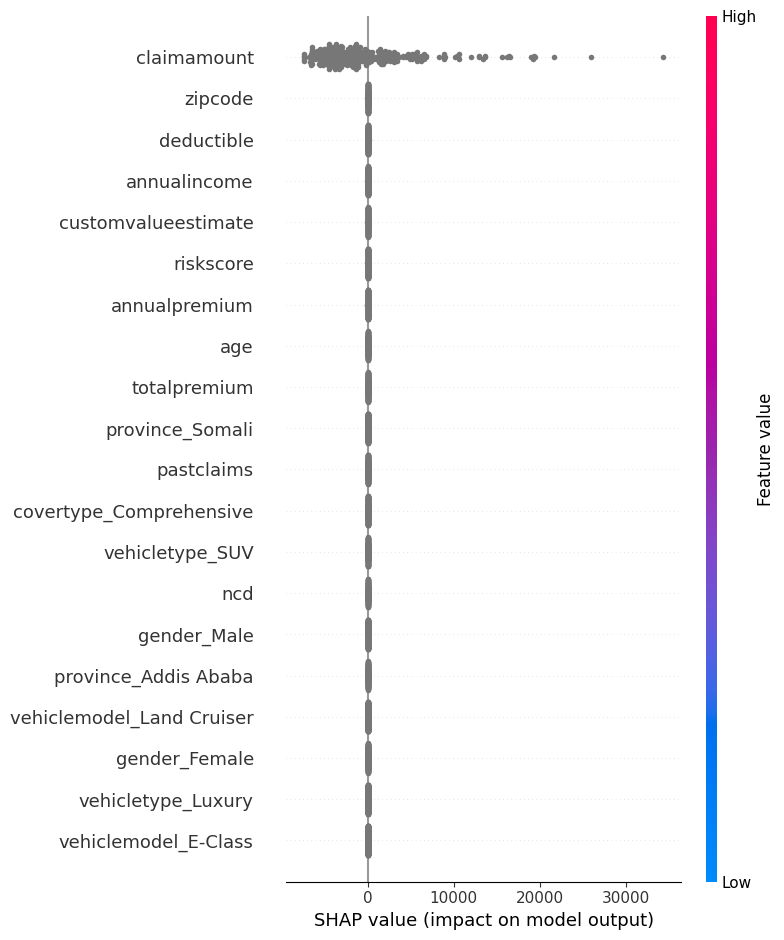

In [44]:
plot_shap_summary(
    shap_values,
    X_test_processed,
    feature_names
)

c:\Users\pc\Desktop\Week 3\insurance-risk-analytics\src\modeling.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  from sklearn.compose import ColumnTransformer


SHAP importance plot saved to outputs/shap_bar.png


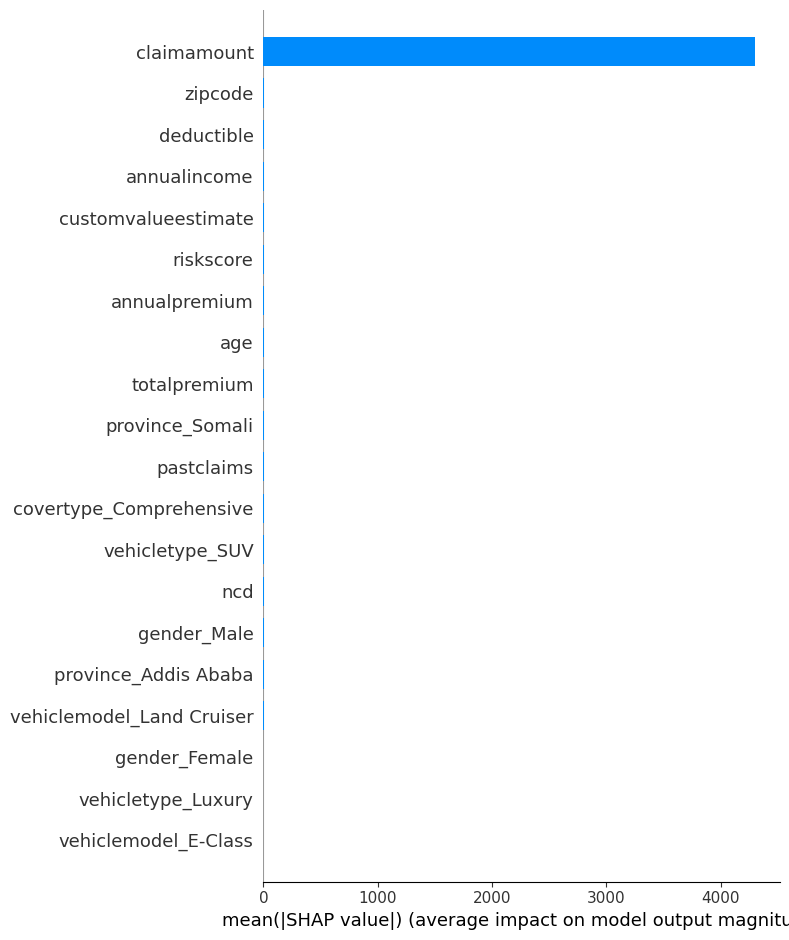

In [47]:
plot_shap_importance(
    shap_values,
    X_test_processed,
    feature_names
)


In [48]:
top_features = get_top_features(
    shap_df,
    top_n=10
)

print("\nTop Influential Features")
print("=" * 50)

print(top_features)


Top Influential Features
claimamount            4305.101783
zipcode                   2.021954
deductible                1.743343
annualincome              1.419792
customvalueestimate       1.038228
riskscore                 0.949138
annualpremium             0.838850
age                       0.817152
totalpremium              0.726626
province_Somali           0.575387
dtype: float64


In [49]:
interpretations = generate_business_interpretation(
    top_features
)

print("\nBusiness Interpretations")
print("=" * 50)

for interpretation in interpretations:
    print(interpretation)


Business Interpretations

Feature: claimamount

Business Impact:
This feature has a strong influence on claim severity predictions.
Higher values or specific categories in claimamount significantly
affect the expected insurance claim amount.

Model Importance Score:
4305.1018


Feature: zipcode

Business Impact:
This feature has a strong influence on claim severity predictions.
Higher values or specific categories in zipcode significantly
affect the expected insurance claim amount.

Model Importance Score:
2.0220


Feature: deductible

Business Impact:
This feature has a strong influence on claim severity predictions.
Higher values or specific categories in deductible significantly
affect the expected insurance claim amount.

Model Importance Score:
1.7433


Feature: annualincome

Business Impact:
This feature has a strong influence on claim severity predictions.
Higher values or specific categories in annualincome significantly
affect the expected insurance claim amount.

Model Impor